# 04 Modeling Pipeline (TinyCNN / TCN)

Notebook này thiết lập, huấn luyện và đánh giá các mô hình học sâu siêu nhẹ (TinyCNN1D, SmallTCN) trên tín hiệu rPPG. 
Quy trình được thực hiện end-to-end từ việc đọc manifest của Task 3, tạo dataset dạng sliding window, trích xuất phổ tần số FFT, chuẩn hóa dữ liệu, huấn luyện mô hình với Early Stopping, và đánh giá so sánh trực tiếp kết quả với các Baseline truyền thống.

## 1. Setup & Imports

In [1]:
from __future__ import annotations

import csv
import json
import logging
import os
import sys
import time
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

# ── repo root resolution (same pattern as Task 1-3) ───────────────────────────
notebook_dir = Path.cwd().resolve()
repo_root = notebook_dir.parent if notebook_dir.name == "notebooks" else notebook_dir
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

# Đảm bảo thư mục làm việc hiện tại là repo root để các đường dẫn tương đối hoạt động chính xác
os.chdir(repo_root)

from airppg.modeling.config import MODELING_SCHEMA_VERSION, ModelingConfig
from airppg.modeling.dataset import (
    WindowDataset,
    apply_normalization,
    fit_normalization,
    load_all_windows,
)
from airppg.modeling.metrics import (
    aggregate_model_metric_rows,
    build_comparison_table,
    compute_hr_metrics,
)
from airppg.modeling.models import build_model
from airppg.modeling.train import save_config, train
from airppg.modeling.visualization import (
    build_sample_visualization,
    plot_comparison_bar,
    plot_training_curves,
)
from airppg.paths import load_json, write_json

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-7s  %(name)s  %(message)s",
    datefmt="%H:%M:%S",
    stream=sys.stdout,
)
logger = logging.getLogger("modeling_notebook")

## 2. Configuration & Hyper-parameters

In [2]:
# Cấu hình các hyper-parameters cho thử nghiệm
MODEL_TYPE = "small_tcn"  # Lựa chọn: 'tiny_cnn' hoặc 'small_tcn'
INPUT_STRATEGY = "pos_spectrum"  # Lựa chọn: 'pos_spectrum', 'fused_spectrum', 'multi_channel_spectrum'
N_FFT_BINS = 64
MAX_EPOCHS = 200
PATIENCE = 30
LR = 1e-3
BATCH_SIZE = 64
SEED = 42

# Để batch_limit = None để chạy trên toàn bộ dataset.
# Đặt số nguyên nhỏ (ví dụ: 5) nếu muốn debug/test chạy nhanh trong vài giây.
BATCH_LIMIT = None
SAVE_FIGURES = True

run_name = f"{MODEL_TYPE}_{INPUT_STRATEGY}"

cfg = ModelingConfig(
    input_strategy=INPUT_STRATEGY,
    model_type=MODEL_TYPE,
    n_fft_bins=N_FFT_BINS,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    lr=LR,
    batch_size=BATCH_SIZE,
    seed=SEED,
    run_name=run_name,
    batch_limit=BATCH_LIMIT,
    save_figures=SAVE_FIGURES,
)

# Hiển thị cấu hình hiện tại dưới dạng bảng
display(pd.DataFrame([cfg.to_dict()]).T.rename(columns={0: "Cấu hình"}))

,Cấu hình
schema_version,modeling_v1
run_name,small_tcn_pos_spectrum
fusion_manifest_path,outputs/fusion/fusion_manifest.json
signal_extraction_manifest_path,outputs/signal_extraction/signal_extraction_da...
modeling_output_root,outputs/modeling
window_sec,30.0
step_sec,1.0
hr_min_bpm,42.0
hr_max_bpm,210.0
input_strategy,pos_spectrum


## 3. Load Manifest & Build Window Datasets

In [3]:
logger.info("Đang load manifests...")
fusion_manifest = load_json(cfg.fusion_manifest_path)
sig_manifest = load_json(cfg.signal_extraction_manifest_path)

logger.info("Đang xây dựng window datasets...")
t0 = time.perf_counter()
split_windows = load_all_windows(cfg, fusion_manifest, sig_manifest)
logger.info(
    f"Đã load xong windows sau {time.perf_counter() - t0:.1f}s: "
    f"train={len(split_windows.get('train', []))}, "
    f"val={len(split_windows.get('val', []))}, "
    f"test={len(split_windows.get('test', []))}"
)

train_windows = split_windows.get("train", [])
val_windows = split_windows.get("val", [])
test_windows = split_windows.get("test", [])

15:30:40  INFO     modeling_notebook  Đang load manifests...


15:30:40  INFO     modeling_notebook  Đang xây dựng window datasets...


15:30:42  INFO     modeling_notebook  Đã load xong windows sau 1.4s: train=1468, val=186, test=206


## 4. Normalization & Dataset Inspection

15:30:42  INFO     modeling_notebook  Đang tính toán chuẩn hóa trên tập train...


15:30:42  INFO     modeling_notebook  Số lượng window hợp lệ thực tế: train=1468, val=186


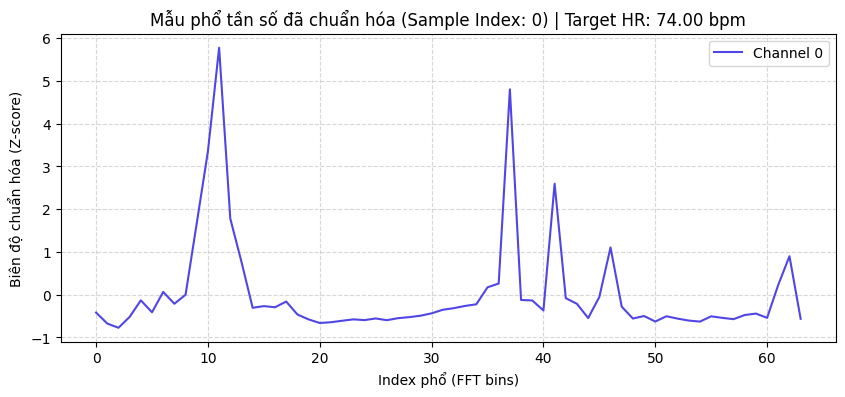

In [4]:
logger.info("Đang tính toán chuẩn hóa trên tập train...")
norm_mean, norm_std = fit_normalization(train_windows)

apply_normalization(train_windows, norm_mean, norm_std)
apply_normalization(val_windows, norm_mean, norm_std)
apply_normalization(test_windows, norm_mean, norm_std)

# Lưu mean/std vào config để inference sau này
cfg.norm_mean = norm_mean.tolist()
cfg.norm_std = norm_std.tolist()

train_ds = WindowDataset(train_windows, valid_only=True)
val_ds = WindowDataset(val_windows, valid_only=True)
logger.info(f"Số lượng window hợp lệ thực tế: train={len(train_ds)}, val={len(val_ds)}")

if len(train_ds) == 0:
    raise ValueError("Không có train windows hợp lệ! Dừng pipeline.")

# Trực quan hóa thử 1 sample spectrum ngẫu nhiên từ tập train
sample_idx = 0
x_sample, y_sample = train_ds[sample_idx]

plt.figure(figsize=(10, 4))
colors = ["#4f46e5", "#10b981", "#ef4444"]
for c in range(x_sample.shape[0]):
    plt.plot(x_sample[c], label=f"Channel {c}", color=colors[c % len(colors)], linewidth=1.5)
plt.title(f"Mẫu phổ tần số đã chuẩn hóa (Sample Index: {sample_idx}) | Target HR: {y_sample.item():.2f} bpm")
plt.xlabel("Index phổ (FFT bins)")
plt.ylabel("Biên độ chuẩn hóa (Z-score)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()

## 5. Model Initialization

In [5]:
cfg.n_input_channels = train_ds.n_channels
cfg.n_input_bins = train_ds.n_bins
model = build_model(cfg.model_type, cfg.n_input_channels, cfg.n_input_bins)
cfg.param_count = model.param_count()  # type: ignore[attr-defined]

logger.info(
    f"Khởi tạo mạng {cfg.model_type} thành công: "
    f"channels={cfg.n_input_channels}, bins={cfg.n_input_bins}, params={cfg.param_count:,}"
)
print("\nCấu trúc chi tiết mô hình:")
print(model)

15:30:42  INFO     modeling_notebook  Khởi tạo mạng small_tcn thành công: channels=1, bins=64, params=25,217



Cấu trúc chi tiết mô hình:
SmallTCN(
  (input_proj): Sequential(
    (0): Conv1d(1, 32, kernel_size=(1,), stride=(1,), bias=False)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (blocks): Sequential(
    (0): _TCNBlock(
      (conv1): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(2,), bias=False)
      (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(2,), bias=False)
      (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (relu): ReLU(inplace=True)
    )
    (1): _TCNBlock(
      (conv1): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,), bias=False)
      (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True

## 6. Model Training (Huấn luyện với Early Stopping)

15:30:42  INFO     modeling_notebook  Bắt đầu huấn luyện mô hình...


15:30:51  INFO     airppg.modeling.train  Training small_tcn | strategy=pos_spectrum | train=1468 val=186 | max_epochs=200 patience=30


15:30:53  INFO     airppg.modeling.train  Epoch   1/200  train_loss=90.7411  val_mae=84.24 bpm  val_rmse=89.87 bpm  ✓ best


15:30:54  INFO     airppg.modeling.train  Epoch   2/200  train_loss=88.8362  val_mae=81.89 bpm  val_rmse=87.31 bpm  ✓ best


15:30:54  INFO     airppg.modeling.train  Epoch   3/200  train_loss=86.9549  val_mae=80.04 bpm  val_rmse=85.34 bpm  ✓ best


...

15:31:50  INFO     airppg.modeling.train  Epoch  70/200  train_loss=4.3598  val_mae=13.75 bpm  val_rmse=29.27 bpm  (patience 15/30)


15:31:59  INFO     airppg.modeling.train  Epoch  80/200  train_loss=4.2605  val_mae=13.34 bpm  val_rmse=28.83 bpm  (patience 25/30)


15:32:04  INFO     airppg.modeling.train  Early stopping at epoch 85 (best val_mae=13.13 bpm)


15:32:04  INFO     airppg.modeling.train  Training history saved to outputs\modeling\checkpoints\small_tcn_pos_spectrum\training_history.csv


15:32:04  INFO     airppg.modeling.train  Config saved to outputs\modeling\checkpoints\small_tcn_pos_spectrum\config.json


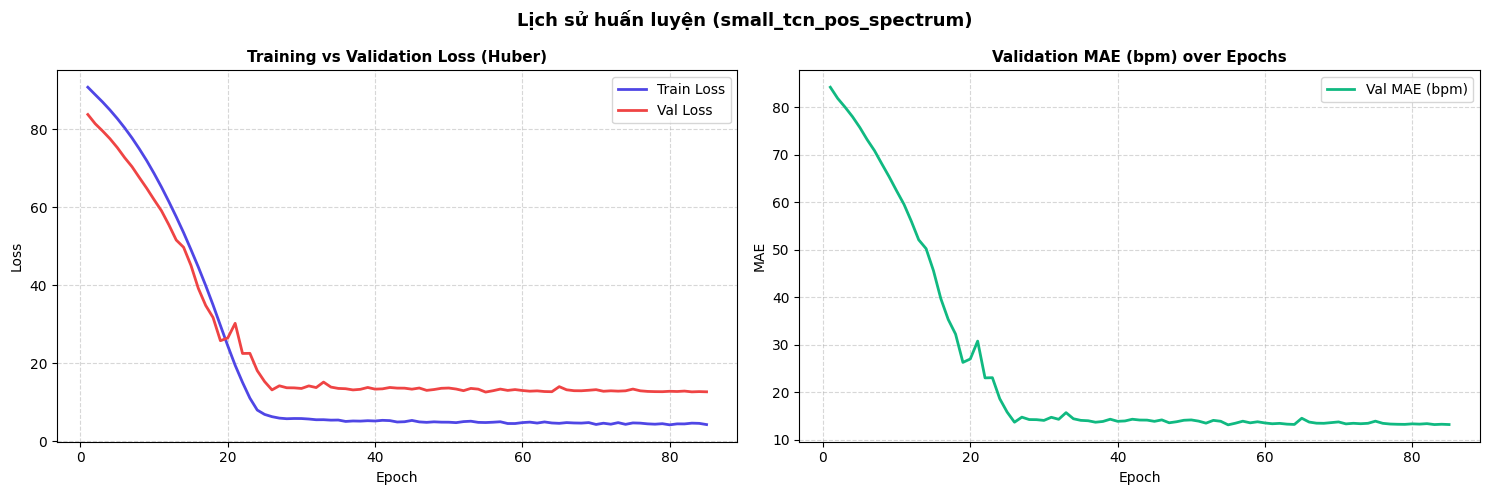

In [6]:
logger.info("Bắt đầu huấn luyện mô hình...")
cfg.progress = True  # In log chi tiết trong cell

model, history = train(model, train_ds, val_ds, cfg)

# Lưu cấu hình config.json cuối cùng chứa normalization
save_config(cfg, cfg.checkpoint_dir / "config.json")

# Vẽ đồ thị huấn luyện loss và validation MAE inline
if history:
    epochs = [h["epoch"] for h in history]
    train_loss = [h["train_loss"] for h in history]
    val_loss = [h["val_loss"] for h in history]
    val_mae = [h["val_mae_bpm"] for h in history]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Loss curve
    ax1.plot(epochs, train_loss, label="Train Loss", color="#4f46e5", linewidth=2)
    ax1.plot(epochs, val_loss, label="Val Loss", color="#ef4444", linewidth=2)
    ax1.set_title("Training vs Validation Loss (Huber)", fontsize=11, fontweight="bold")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.grid(True, linestyle="--", alpha=0.5)
    ax1.legend()
    
    # MAE curve
    ax2.plot(epochs, val_mae, label="Val MAE (bpm)", color="#10b981", linewidth=2)
    ax2.set_title("Validation MAE (bpm) over Epochs", fontsize=11, fontweight="bold")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("MAE")
    ax2.grid(True, linestyle="--", alpha=0.5)
    ax2.legend()
    
    plt.suptitle(f"Lịch sử huấn luyện ({cfg.run_name})", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

## 7. Inference & Per-sample Predictions

In [7]:
device = torch.device("cpu")
all_metric_rows: list[dict[str, Any]] = []
manifest_items: list[dict[str, Any]] = []

def _infer_sample_local(model: torch.nn.Module, windows: list, device: torch.device) -> np.ndarray:
    predicted = np.full(len(windows), float("nan"), dtype=np.float32)
    model.eval()
    for idx, w in enumerate(windows):
        if not w.valid:
            continue
        x = torch.as_tensor(w.features, dtype=torch.float32).unsqueeze(0).to(device)
        pred = model(x)
        predicted[idx] = float(pred.squeeze().item())
    return predicted

def _save_predictions_npz_local(
    path: Path,
    sample_id: str,
    split: str,
    model_name: str,
    input_strategy: str,
    hr_timestamps: np.ndarray,
    gt_aligned_to_hr: np.ndarray,
    predicted_hr: np.ndarray,
    baseline_hr: np.ndarray | None,
    baseline_names: list[str],
    valid_windows: np.ndarray,
) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    arrays: dict[str, Any] = {
        "schema_version": np.array(MODELING_SCHEMA_VERSION),
        "sample_id": np.array(sample_id),
        "split": np.array(split),
        "model_name": np.array(model_name),
        "hr_timestamps": hr_timestamps.astype(np.float32),
        "gt_aligned_to_hr": gt_aligned_to_hr.astype(np.float32),
        "predicted_hr": predicted_hr.astype(np.float32),
        "input_strategy_names": np.array([input_strategy]),
        "valid_windows": valid_windows.astype(bool),
    }
    if baseline_hr is not None and len(baseline_hr) > 0:
        arrays["baseline_hr"] = baseline_hr.astype(np.float32)
        arrays["baseline_names"] = np.array(baseline_names)
    np.savez_compressed(path, **arrays)

logger.info("Bắt đầu chạy đánh giá và lưu kết quả...")
for split_name, windows in [
    ("train", train_windows),
    ("val", val_windows),
    ("test", test_windows),
]:
    sample_groups: dict[str, list] = {}
    for w in windows:
        sample_groups.setdefault(w.sample_id, []).append(w)

    for sample_id, s_windows in sample_groups.items():
        hr_timestamps = np.array([w.hr_timestamp for w in s_windows], dtype=np.float32)
        gt_aligned = np.array([w.gt_hr for w in s_windows], dtype=np.float32)
        valid_windows_arr = np.array([w.valid for w in s_windows], dtype=bool)
        invalid_reasons = [w.invalid_reason for w in s_windows]

        # Infer
        t_infer = time.perf_counter()
        predicted_hr = _infer_sample_local(model, s_windows, device)
        inference_ms = (time.perf_counter() - t_infer) * 1000.0

        # Metrics
        metrics = compute_hr_metrics(predicted_hr, gt_aligned, valid_windows_arr)
        metrics["inference_ms_total"] = round(inference_ms, 2)
        metrics["inference_ms_per_window"] = (
            round(inference_ms / len(s_windows), 3) if s_windows else float("nan")
        )

        # Load baseline
        baseline_hr_dict: dict[str, np.ndarray] = {}
        baseline_np: np.ndarray | None = None
        baseline_names: list[str] = []

        fusion_items_map = {
            item["sample_id"]: item
            for item in fusion_manifest.get("items", [])
            if item.get("status") == "processed"
        }
        if sample_id in fusion_items_map:
            fusion_item = fusion_items_map[sample_id]
            fusion_root = Path(cfg.fusion_manifest_path).parent
            npz_path = fusion_root / fusion_item["outputs"]["fusion_npz"]
            if npz_path.exists():
                with np.load(npz_path, allow_pickle=False) as d:
                    if "average_fusion_hr" in d.files:
                        baseline_hr_dict["average_fusion"] = d["average_fusion_hr"][:, 2]
                    if "weighted_fusion_hr" in d.files:
                        baseline_hr_dict["quality_weighted_fusion"] = d["weighted_fusion_hr"][:, 2]
                    if "baseline_hr" in d.files:
                        bhr = d["baseline_hr"]
                        for mi, mname in enumerate(["task2_green", "task2_chrom", "task2_pos"]):
                            baseline_hr_dict[mname] = bhr[:, mi]

        if baseline_hr_dict:
            baseline_names = list(baseline_hr_dict.keys())
            baseline_np = np.stack(list(baseline_hr_dict.values()), axis=1)

        # Lưu outputs
        out_dir = cfg.modeling_output_root / split_name / sample_id
        out_dir.mkdir(parents=True, exist_ok=True)
        npz_path_out = out_dir / "model_predictions.npz"
        metrics_json_path = out_dir / "model_metrics.json"
        metrics_csv_path = out_dir / "model_metrics.csv"
        vis_path = out_dir / "model_visualization.png"

        _save_predictions_npz_local(
            npz_path_out,
            sample_id=sample_id,
            split=split_name,
            model_name=cfg.run_name,
            input_strategy=cfg.input_strategy,
            hr_timestamps=hr_timestamps,
            gt_aligned_to_hr=gt_aligned,
            predicted_hr=predicted_hr,
            baseline_hr=baseline_np,
            baseline_names=baseline_names,
            valid_windows=valid_windows_arr,
        )

        metrics_full = {
            "schema_version": MODELING_SCHEMA_VERSION,
            "sample_id": sample_id,
            "split": split_name,
            "model_name": cfg.run_name,
            "input_strategy": cfg.input_strategy,
            "model_type": cfg.model_type,
            "param_count": cfg.param_count,
            "n_windows_total": len(s_windows),
            "n_windows_valid": int(valid_windows_arr.sum()),
            "n_windows_invalid": int((~valid_windows_arr).sum()),
            "invalid_reasons": [r for r in invalid_reasons if r],
            **metrics,
        }
        write_json(metrics_json_path, metrics_full)

        with metrics_csv_path.open("w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(
                f,
                fieldnames=["sample_id", "split", "model_name", "strategy",
                            "mae_bpm", "rmse_bpm", "pearson_r", "bias_bpm", "n_windows"],
            )
            writer.writeheader()
            writer.writerow({
                "sample_id": sample_id,
                "split": split_name,
                "model_name": cfg.run_name,
                "strategy": cfg.input_strategy,
                "mae_bpm": metrics.get("mae_bpm"),
                "rmse_bpm": metrics.get("rmse_bpm"),
                "pearson_r": metrics.get("pearson_r"),
                "bias_bpm": metrics.get("bias_bpm"),
                "n_windows": metrics.get("n_windows"),
            })

        if cfg.save_figures:
            fig = build_sample_visualization(
                hr_timestamps=hr_timestamps,
                gt_hr=gt_aligned,
                predicted_hr=predicted_hr,
                baseline_hr=baseline_hr_dict if baseline_hr_dict else None,
                sample_id=sample_id,
                model_name=cfg.run_name,
                metrics=metrics,
                output_path=vis_path,
            )
            plt.close(fig)

        metric_row = {
            "sample_id": sample_id,
            "split": split_name,
            "model_name": cfg.run_name,
            "strategy": cfg.input_strategy,
            **{k: v for k, v in metrics.items()
               if k in ("mae_bpm", "rmse_bpm", "pearson_r", "bias_bpm", "n_windows")},
        }
        all_metric_rows.append(metric_row)

        manifest_items.append({
            "sample_id": sample_id,
            "split": split_name,
            "status": "processed",
            "model_name": cfg.run_name,
            "n_windows_total": len(s_windows),
            "n_windows_valid": int(valid_windows_arr.sum()),
            "outputs": {
                "predictions_npz": (npz_path_out.relative_to(cfg.modeling_output_root)).as_posix(),
                "metrics_json": (metrics_json_path.relative_to(cfg.modeling_output_root)).as_posix(),
                "metrics_csv": (metrics_csv_path.relative_to(cfg.modeling_output_root)).as_posix(),
                "visualization_png": (vis_path.relative_to(cfg.modeling_output_root)).as_posix(),
            },
        })
logger.info("Đánh giá hoàn tất!")

15:32:04  INFO     modeling_notebook  Bắt đầu chạy đánh giá và lưu kết quả...


15:32:20  INFO     modeling_notebook  Đánh giá hoàn tất!


## 8. Visualizing Heart Rate Predictions vs Ground Truth

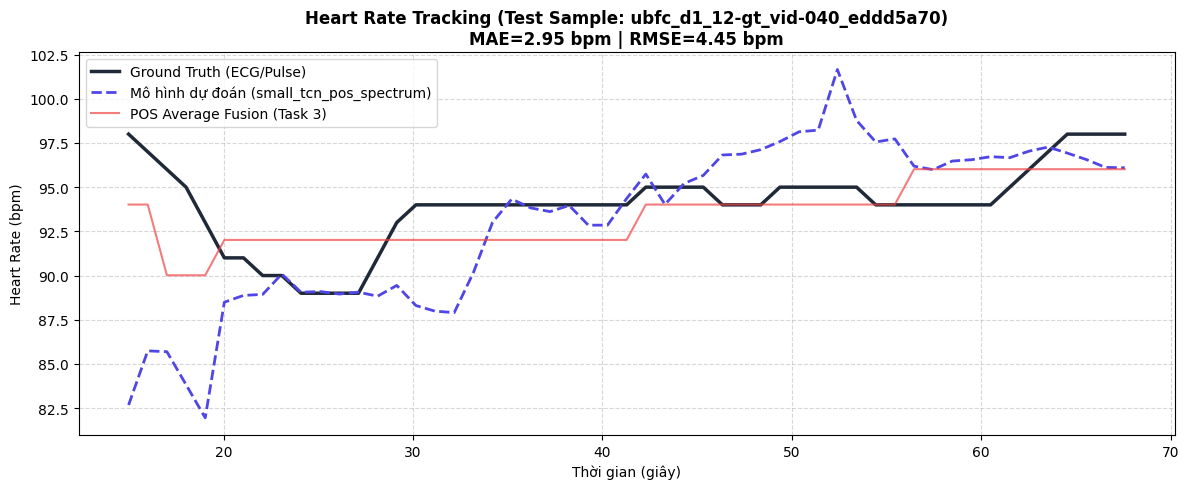

In [8]:
# Lấy 1 sample từ tập test để vẽ biểu đồ so sánh nhịp tim trực quan
test_items = [item for item in manifest_items if item["split"] == "test"]
if test_items:
    sample_item = test_items[0]
    sid = sample_item["sample_id"]
    npz_path_item = cfg.modeling_output_root / sample_item["outputs"]["predictions_npz"]
    json_path_item = cfg.modeling_output_root / sample_item["outputs"]["metrics_json"]
    
    with np.load(npz_path_item, allow_pickle=True) as d:
        hr_ts = d["hr_timestamps"]
        gt_hr = d["gt_aligned_to_hr"]
        pred_hr = d["predicted_hr"]
        
        # Đọc average fusion POS baseline để so sánh
        pos_baseline = None
        if "baseline_hr" in d.files and "baseline_names" in d.files:
            names_list = list(d["baseline_names"])
            if "average_fusion" in names_list:
                pos_baseline = d["baseline_hr"][:, names_list.index("average_fusion")]
                
    with open(json_path_item, "r", encoding="utf-8") as f:
        item_metrics = json.load(f)
        
    plt.figure(figsize=(12, 5))
    plt.plot(hr_ts, gt_hr, label="Ground Truth (ECG/Pulse)", color="#1f2937", linewidth=2.5)
    plt.plot(hr_ts, pred_hr, label=f"Mô hình dự đoán ({cfg.run_name})", color="#4f46e5", linewidth=2, linestyle="--")
    if pos_baseline is not None:
        plt.plot(hr_ts, pos_baseline, label="POS Average Fusion (Task 3)", color="#ef4444", linewidth=1.5, alpha=0.7)
    
    plt.title(f"Heart Rate Tracking (Test Sample: {sid})\nMAE={item_metrics.get('mae_bpm'):.2f} bpm | RMSE={item_metrics.get('rmse_bpm'):.2f} bpm", fontsize=12, fontweight="bold")
    plt.xlabel("Thời gian (giây)")
    plt.ylabel("Heart Rate (bpm)")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Không có test samples để trực quan hóa.")

## 9. Baseline Comparisons & Performance Charts

15:32:20  INFO     modeling_notebook  Đã ghi bảng so sánh tại: outputs\modeling\comparison_table_test.csv


,source,method,strategy,mae_bpm,rmse_bpm,pearson_r,bias_bpm
12,task3_fusion,pos,quality_weighted_fusion,1.642082,2.103469,0.465678,-1.044562
11,task3_fusion,pos,average_fusion,1.663169,2.115390,0.466912,-1.075864
18,task2_signal,pos,task2_pos,1.663232,2.115374,0.466911,-1.075379
13,task3_fusion,pos,single_forehead,1.795678,2.326895,0.423097,-1.175683
15,task3_fusion,pos,single_right_cheek,2.791617,5.161262,0.368778,-2.214674
14,task3_fusion,pos,single_left_cheek,3.232056,5.450659,0.414734,-2.777020
0,model,small_tcn_pos_spectrum,pos_spectrum,4.121255,5.140588,0.129142,-2.862539
6,task3_fusion,green,average_fusion,10.243720,12.091019,0.519198,-9.796645
17,task2_signal,green,task2_green,10.243733,12.090977,0.519198,-9.796150
7,task3_fusion,green,quality_weighted_fusion,11.686996,15.594323,0.407255,-11.290918


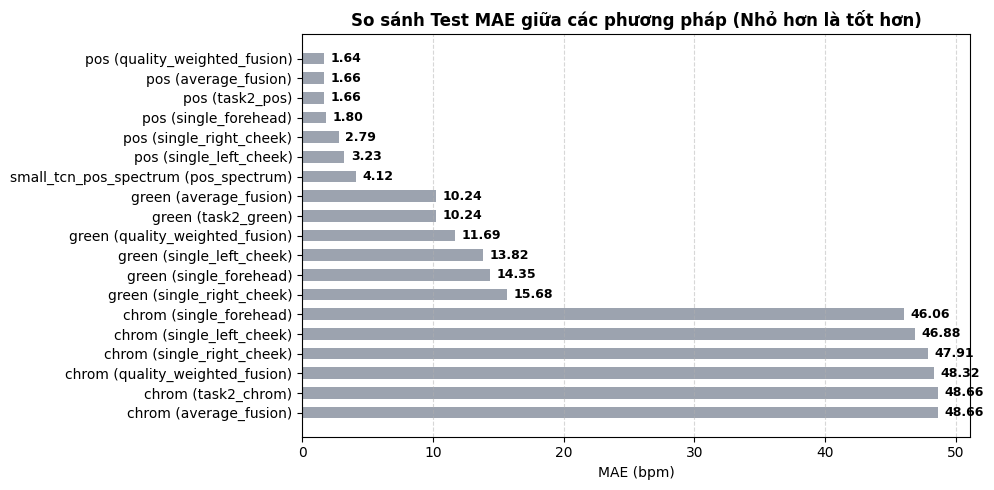

In [9]:
aggregate_rows = aggregate_model_metric_rows(all_metric_rows)

# Lưu summaries thành CSV
summary_csv = cfg.modeling_output_root / "modeling_metrics_summary.csv"
with summary_csv.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=list(all_metric_rows[0].keys()))
    writer.writeheader()
    writer.writerows(all_metric_rows)

agg_csv = cfg.modeling_output_root / "modeling_aggregate_summary.csv"
with agg_csv.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=list(aggregate_rows[0].keys()))
    writer.writeheader()
    writer.writerows(aggregate_rows)

# Đọc baseline của các Task trước để so sánh trên tập Test
fusion_agg_csv = Path("outputs/fusion/fusion_aggregate_summary.csv")
sig_metrics_csv = Path("outputs/signal_extraction/signal_extraction_metrics_summary.csv")

comparison_df = build_comparison_table(
    aggregate_rows,
    fusion_agg_csv,
    sig_metrics_csv,
    split="test",
)

if not comparison_df.empty:
    # Lưu bảng so sánh
    comp_csv = cfg.modeling_output_root / "comparison_table_test.csv"
    comparison_df.to_csv(comp_csv, index=False)
    logger.info(f"Đã ghi bảng so sánh tại: {comp_csv}")
    
    # Hiển thị bảng so sánh dưới dạng pandas
    display(comparison_df.sort_values("mae_bpm"))
    
    # Vẽ biểu đồ so sánh MAE (càng nhỏ càng tốt)
    plt.figure(figsize=(10, 5))
    df_sorted = comparison_df.sort_values("mae_bpm", ascending=False)
    methods = df_sorted["method"] + " (" + df_sorted["strategy"] + ")"
    maes = df_sorted["mae_bpm"]
    
    # Highlight model mới bằng màu nổi bật
    colors = ["#4f46e5" if "model" in m.lower() else "#9ca3af" for m in methods]
    
    bars = plt.barh(methods, maes, color=colors, height=0.6)
    plt.title("So sánh Test MAE giữa các phương pháp (Nhỏ hơn là tốt hơn)", fontsize=12, fontweight="bold")
    plt.xlabel("MAE (bpm)")
    plt.grid(True, axis="x", linestyle="--", alpha=0.5)
    
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, f"{width:.2f}", 
                 va="center", ha="left", fontsize=9, fontweight="bold")

    plt.tight_layout()
    
    # Lưu hình ảnh vào assets
    assets_dir = Path("report/assets")
    assets_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(assets_dir / f"task4_{cfg.run_name}_comparison_mae.png", dpi=150)
    plt.show()
else:
    logger.warning("Không tìm thấy dữ liệu baseline để so sánh.")

## 10. Save Modeling Manifest

In [10]:
counts = {
    "total": len(manifest_items),
    "processed": sum(1 for i in manifest_items if i["status"] == "processed"),
    "failed": sum(1 for i in manifest_items if i["status"] != "processed"),
    "train": sum(1 for i in manifest_items if i["split"] == "train"),
    "val": sum(1 for i in manifest_items if i["split"] == "val"),
    "test": sum(1 for i in manifest_items if i["split"] == "test"),
}
manifest = {
    "schema_version": MODELING_SCHEMA_VERSION,
    "fusion_manifest": str(cfg.fusion_manifest_path),
    "output_root_hint": str(cfg.modeling_output_root),
    "config": cfg.to_dict(),
    "counts": counts,
    "items": manifest_items,
}
manifest_path = cfg.modeling_output_root / "modeling_manifest.json"
write_json(manifest_path, manifest)
logger.info(f"Đã ghi modeling manifest tại: {manifest_path}")

# In tóm tắt kết quả tập test cuối cùng
test_rows = [r for r in all_metric_rows if r["split"] == "test"]
if test_rows:
    test_mae_vals = [r["mae_bpm"] for r in test_rows if r["mae_bpm"] is not None]
    test_rmse_vals = [r["rmse_bpm"] for r in test_rows if r["rmse_bpm"] is not None]
    print("\n" + "=" * 50)
    print("TỔNG KẾT KẾT QUẢ TRÊN TẬP TEST")
    print(f"MAE:  {np.nanmean(test_mae_vals):.2f} ± {np.nanstd(test_mae_vals):.2f} bpm")
    print(f"RMSE: {np.nanmean(test_rmse_vals):.2f} ± {np.nanstd(test_rmse_vals):.2f} bpm")
    print(f"Tổng số mẫu đánh giá: {len(test_rows)} video")
    print("=" * 50)

15:32:21  INFO     modeling_notebook  Đã ghi modeling manifest tại: outputs\modeling\modeling_manifest.json



TỔNG KẾT KẾT QUẢ TRÊN TẬP TEST
MAE:  4.12 ± 1.42 bpm
RMSE: 5.14 ± 1.77 bpm
Tổng số mẫu đánh giá: 5 video
